In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [4]:
df.describe()

,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [5]:
df.sample(5)

,date,store_id,item_id,sales,price,promo,weekday,month
59358,2021-07-15,store_1,item_33,28,41.50,0,3,7
1400004,2022-07-12,store_16,item_17,13,53.22,0,1,7
1923109,2019-11-28,store_22,item_4,29,50.95,0,3,11
1628932,2019-05-21,store_18,item_43,43,27.93,0,1,5
2038592,2021-02-15,store_23,item_17,30,24.18,1,0,2


In [6]:
df.shape

(4565000, 8)

In [7]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='item_id', ylabel='sales'>

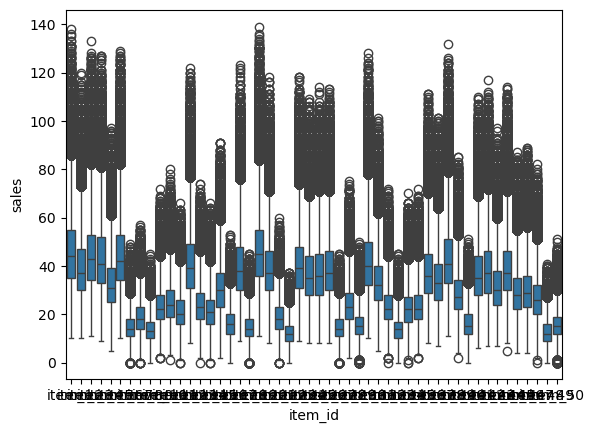

In [9]:
sns.boxplot(data=df, x="item_id", y="sales")

In [10]:
zero_sales = df[df['sales'] == 0]
print(zero_sales)
print(len(zero_sales))

               date  store_id  item_id  sales  price  promo  weekday  month
11226    2019-09-28   store_1   item_7      0  65.21      0        5      9
11255    2019-10-27   store_1   item_7      0  65.21      0        6     10
14858    2019-09-08   store_1   item_9      0  21.93      0        6      9
15682    2021-12-10   store_1   item_9      0  21.93      0        4     12
40436    2019-09-22   store_1  item_23      0  46.82      0        6      9
...             ...       ...      ...    ...    ...    ...      ...    ...
4561639  2019-10-19  store_50  item_49      0  38.72      0        5     10
4561668  2019-11-17  store_50  item_49      0  38.72      0        6     11
4561709  2019-12-28  store_50  item_49      0  38.72      0        5     12
4562010  2020-10-24  store_50  item_49      0  38.72      0        5     10
4564907  2023-09-30  store_50  item_50      0  80.12      0        5      9

[1037 rows x 8 columns]
1037


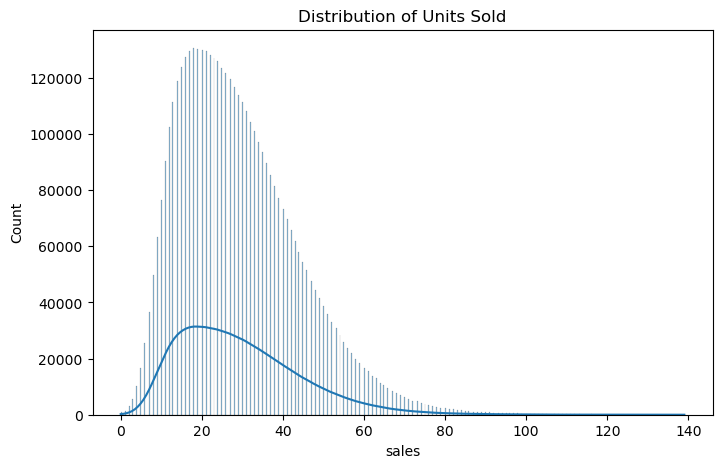

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["sales"], kde=True)
plt.title("Distribution of Units Sold")
plt.show()

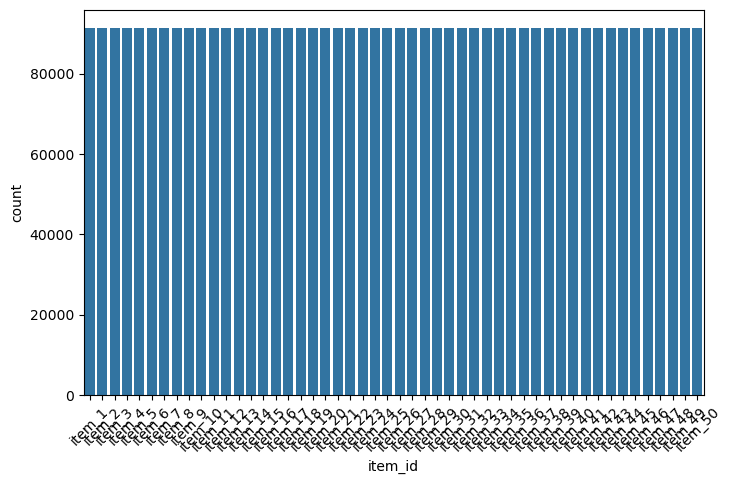

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="item_id")
plt.xticks(rotation=45)
plt.show()

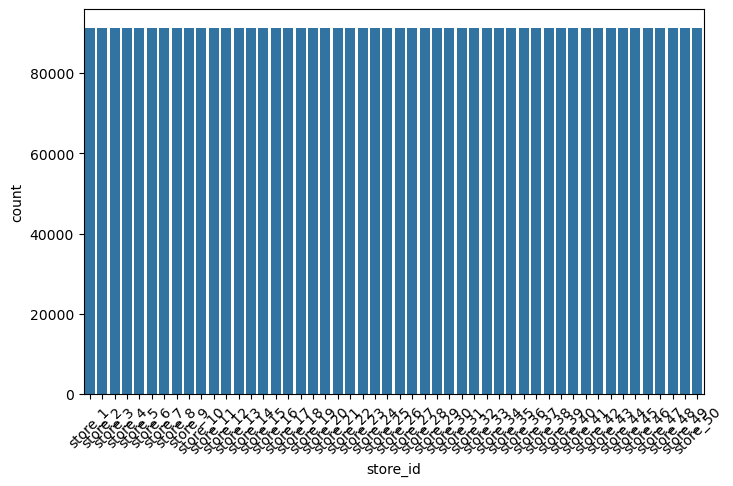

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="store_id")
plt.xticks(rotation=45)
plt.show()

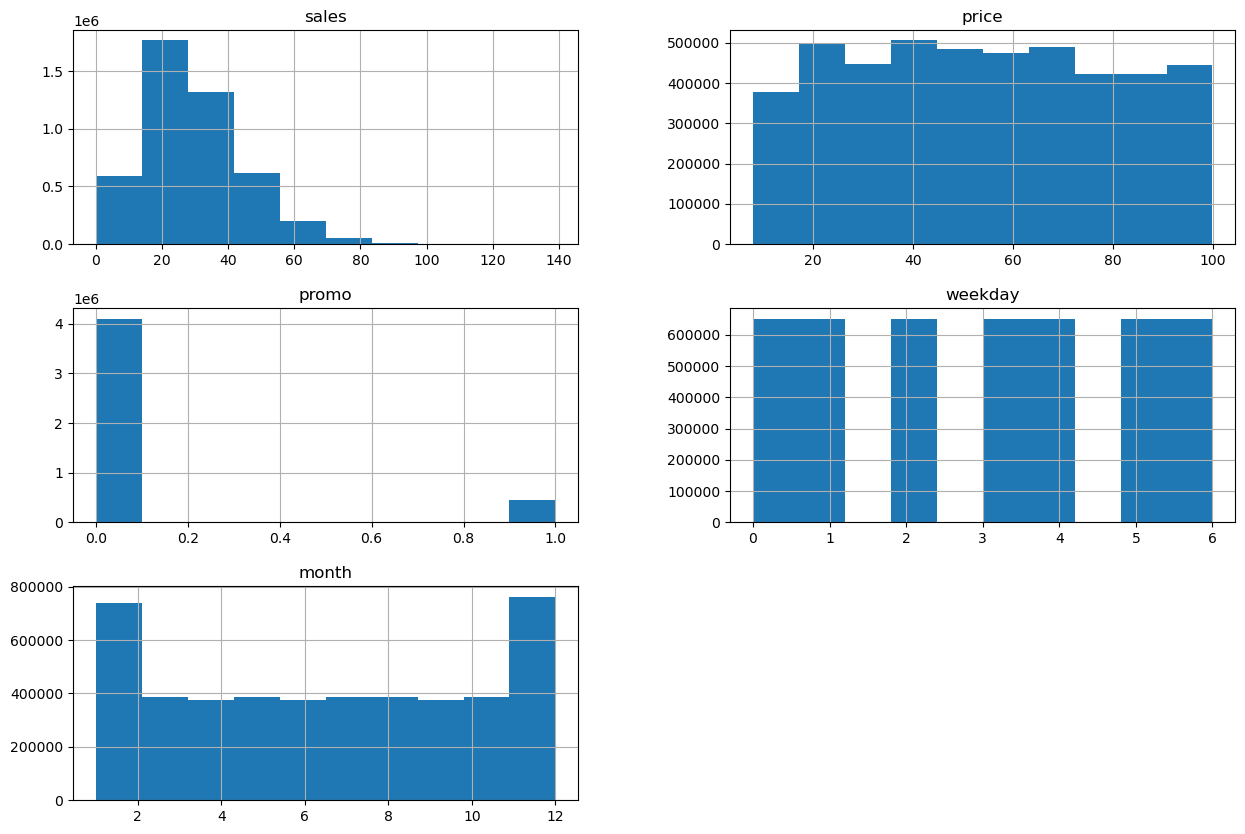

In [14]:
df.hist(figsize=(15,10))
plt.show()

<Axes: xlabel='price', ylabel='sales'>

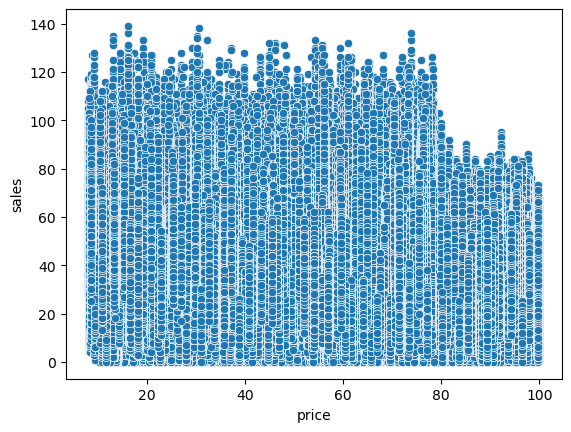

In [15]:
sns.scatterplot(data=df, x="price", y="sales")

<Axes: xlabel='promo', ylabel='sales'>

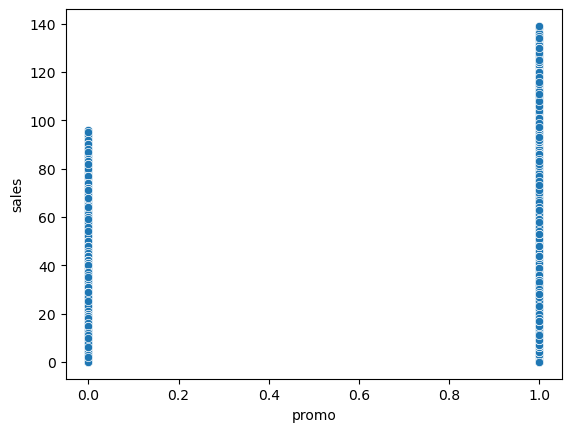

In [16]:
sns.scatterplot(data=df, x="promo", y="sales")

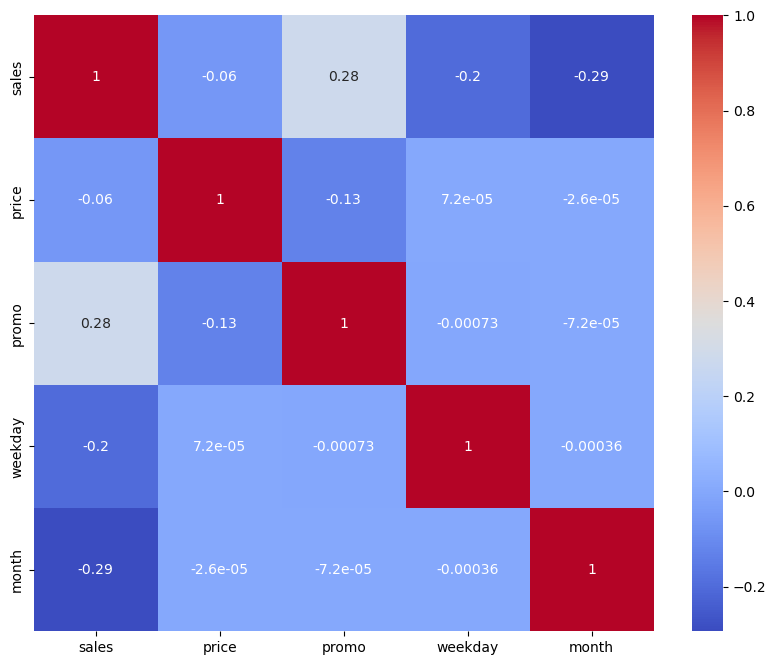

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

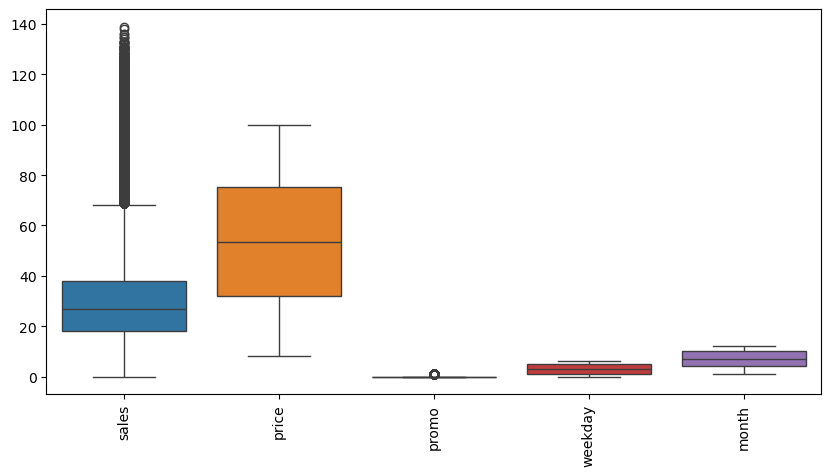

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [19]:
print(df['promo'].unique())

[0 1]


In [20]:
df['date'] = pd.to_datetime(df['date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[ns]
 1   store_id  object        
 2   item_id   object        
 3   sales     int64         
 4   price     float64       
 5   promo     int64         
 6   weekday   int64         
 7   month     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 278.6+ MB


In [22]:
df['year'] = df['date'].dt.year
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['date'].dt.dayofweek >=5).astype(int)

In [23]:
df.head(10)

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,week,quarter,is_weekend
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,2019,1,1,1,0
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2019,2,1,1,0
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,2019,3,1,1,0
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,2019,4,1,1,0
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,2019,5,1,1,1
5,2019-01-06,store_1,item_1,38,21.30,0,6,1,2019,6,1,1,1
6,2019-01-07,store_1,item_1,45,21.30,0,0,1,2019,7,2,1,0
7,2019-01-08,store_1,item_1,48,21.30,0,1,1,2019,8,2,1,0
8,2019-01-09,store_1,item_1,50,21.30,0,2,1,2019,9,2,1,0
9,2019-01-10,store_1,item_1,44,21.30,0,3,1,2019,10,2,1,0


In [24]:
df = df.sort_values(['store_id', 'item_id', 'date'])

df['sales_lag_1'] = (df.groupby(['store_id', 'item_id'])['sales'].shift(1))

df['sales_lag_7'] = (df.groupby(['store_id', 'item_id'])['sales'].shift(7))

df['sales_lag_14'] = (df.groupby(['store_id', 'item_id'])['sales'].shift(14))

df['sales_lag_28'] = (df.groupby(['store_id', 'item_id'])['sales'].shift(28))

In [25]:
group = df.groupby(['store_id', 'item_id'])['sales']

df['sales_rolling_mean_7'] = (group.shift(1).rolling(7).mean())

df['sales_rolling_mean_28'] = (group.shift(1).rolling(28).mean())

In [ ]:
df['sales_rolling_mean_7'] = (
    df.groupby(['store_id', 'item_id'])['sales']
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df['sales_rolling_mean_28'] = (
    df.groupby(['store_id', 'item_id'])['sales']
      .transform(lambda x: x.shift(1).rolling(28).mean())
)

df['sales_rolling_std_7'] = (
    df.groupby(['store_id', 'item_id'])['sales']
      .transform(lambda x: x.shift(1).rolling(7).std()))

In [26]:
df['sales_rolling_std_7'] = (group.shift(1).rolling(7).std())

In [27]:
df['price_change'] = (df.groupby(['store_id', 'item_id'])['price'].pct_change())

In [28]:
df['promo_lag_1'] = (df.groupby(['store_id', 'item_id'])['promo'].shift(1))

df['promo_lag_7'] = (df.groupby(['store_id', 'item_id'])['promo'].shift(7))

In [29]:
print(df.groupby(['store_id', 'item_id'])['date'].count().describe())

count    2500.0
mean     1826.0
std         0.0
min      1826.0
25%      1826.0
50%      1826.0
75%      1826.0
max      1826.0
Name: date, dtype: float64


In [30]:
print(df['date'].min())
print(df['date'].max())
print(df['date'].nunique())

2019-01-01 00:00:00
2023-12-31 00:00:00
1826


In [31]:
df.sample(10)

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rolling_mean_7,sales_rolling_mean_28,sales_rolling_std_7,price_change,promo_lag_1,promo_lag_7
3396069,2023-03-16,store_38,item_10,24,77.81,0,3,3,2023,16,...,29.0,31.0,30.0,44.0,26.714286,28.571429,3.450328,0.0,0.0,0.0
352641,2019-08-12,store_4,item_44,19,20.05,0,0,8,2019,12,...,20.0,20.0,31.0,30.0,23.142857,26.250000,4.220133,0.0,0.0,0.0
2269137,2022-05-30,store_25,item_43,48,24.70,0,0,5,2022,30,...,36.0,47.0,45.0,50.0,48.857143,50.214286,14.473292,0.0,0.0,0.0
3624663,2019-02-23,store_40,item_36,22,59.08,0,5,2,2019,23,...,24.0,16.0,21.0,18.0,24.714286,23.464286,6.102302,0.0,0.0,0.0
786369,2022-04-04,store_9,item_31,55,85.34,0,0,4,2022,4,...,46.0,52.0,58.0,60.0,57.428571,58.392857,8.791229,0.0,0.0,0.0
1107913,2022-09-19,store_13,item_7,13,13.61,0,0,9,2022,19,...,5.0,17.0,15.0,15.0,12.714286,12.428571,4.270608,0.0,0.0,1.0
2109252,2019-08-11,store_24,item_6,22,54.18,0,6,8,2019,11,...,27.0,22.0,15.0,26.0,30.857143,31.892857,6.283008,0.0,0.0,0.0
1426805,2020-11-30,store_16,item_32,24,83.83,0,0,11,2020,30,...,17.0,29.0,22.0,20.0,23.714286,22.857143,7.341986,0.0,0.0,0.0
4184560,2022-04-09,store_46,item_42,41,99.70,0,5,4,2022,9,...,44.0,38.0,43.0,43.0,55.142857,54.178571,17.957622,0.0,0.0,0.0
3611059,2021-11-23,store_40,item_28,11,92.32,0,1,11,2021,23,...,10.0,12.0,9.0,13.0,11.142857,10.392857,3.023716,0.0,0.0,0.0


In [32]:
df.select_dtypes(include = 'object').columns

Index(['store_id', 'item_id'], dtype='object')

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [34]:
le = LabelEncoder()

for column in df.select_dtypes(include = 'object').columns:
    df[column] = le.fit_transform(df[column])

In [35]:
df.sample(5)

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rolling_mean_7,sales_rolling_mean_28,sales_rolling_std_7,price_change,promo_lag_1,promo_lag_7
2793506,2023-04-02,24,23,20,48.15,0,6,4,2023,2,...,20.0,15.0,25.0,18.0,21.571429,23.464286,4.503967,0.000000,0.0,0.0
357374,2022-07-28,33,40,28,17.50,0,3,7,2022,28,...,31.0,34.0,33.0,34.0,27.142857,29.428571,4.670067,0.000000,0.0,0.0
895872,2022-02-06,1,35,27,25.57,1,6,2,2022,6,...,19.0,15.0,18.0,14.0,20.285714,19.357143,3.147183,-0.200188,0.0,0.0
160666,2023-12-10,11,31,35,21.69,0,6,12,2023,10,...,30.0,30.0,32.0,24.0,48.142857,39.428571,14.803474,0.000000,0.0,0.0
914590,2023-05-10,2,0,59,37.69,0,2,5,2023,10,...,61.0,61.0,60.0,65.0,54.142857,53.821429,12.837816,0.000000,0.0,0.0


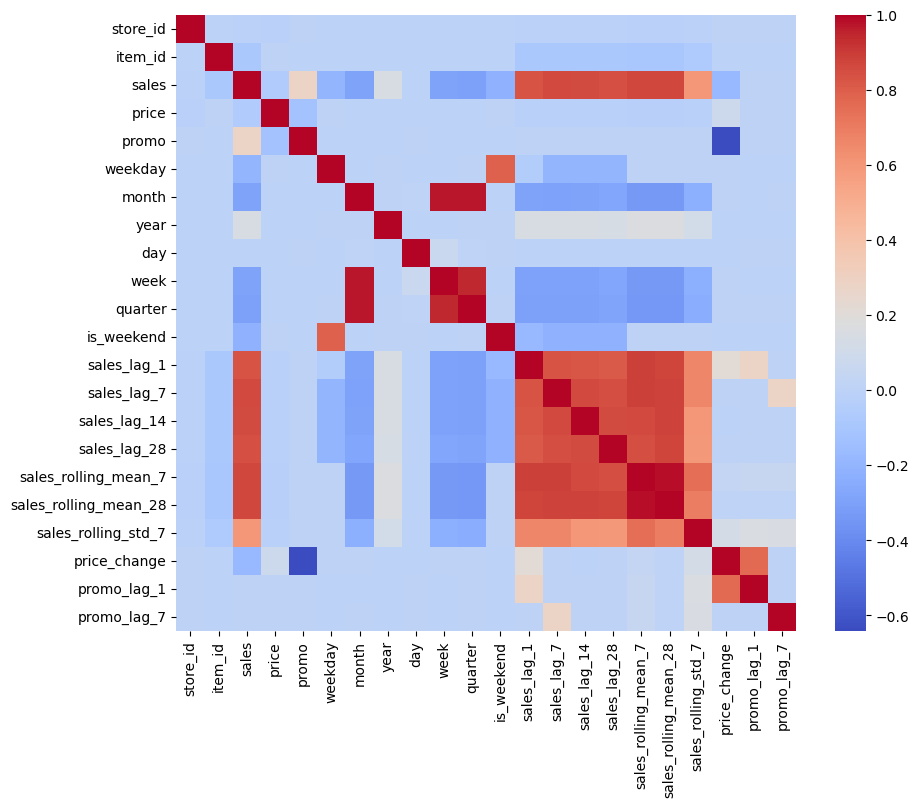

In [36]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

promo                    2.666692
promo_lag_1              2.666672
promo_lag_7              2.666668
sales_rolling_std_7      1.446786
is_weekend               0.947835
sales_lag_28             0.946603
sales_lag_14             0.944918
sales_lag_7              0.943712
sales_lag_1              0.942453
sales                    0.942396
price_change             0.636322
sales_rolling_mean_7     0.603577
sales_rolling_mean_28    0.582620
price                    0.054276
day                      0.006912
year                     0.000968
week                     0.000523
store_id                 0.000000
item_id                  0.000000
weekday                 -0.000615
month                   -0.009526
quarter                 -0.011353
dtype: float64


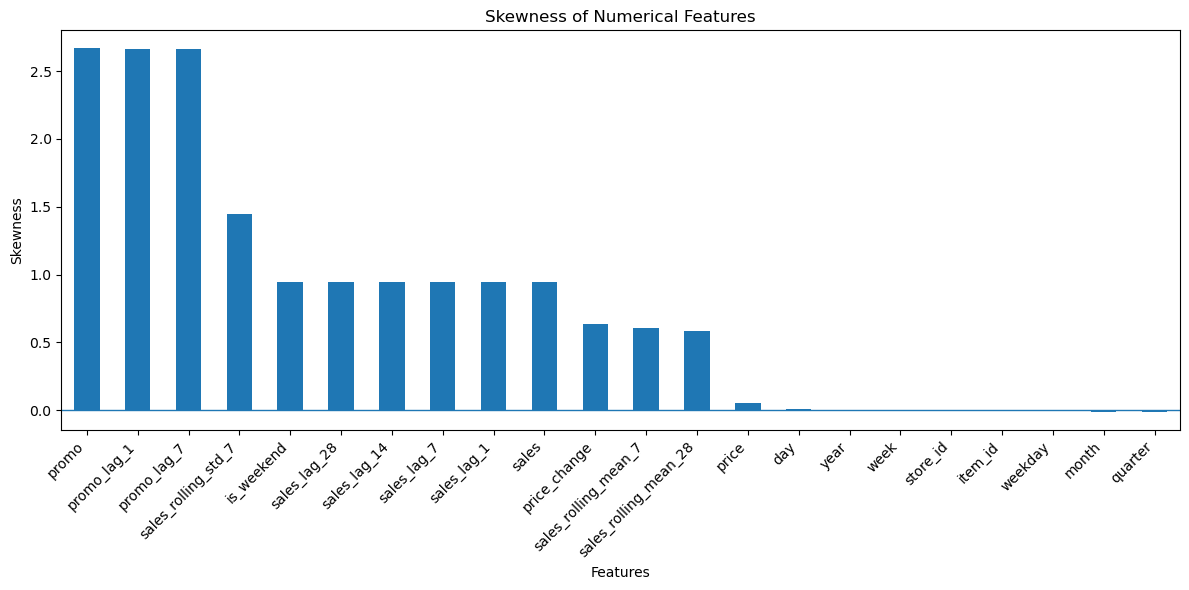

In [37]:
# Select numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Calculate skewness
skewness = df[numeric_cols].skew().sort_values(ascending=False)

# Display skewness values
print(skewness)

# Plot skewness
plt.figure(figsize=(12, 6))
skewness.plot(kind='bar')

plt.axhline(y=0, linewidth=1)
plt.title('Skewness of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

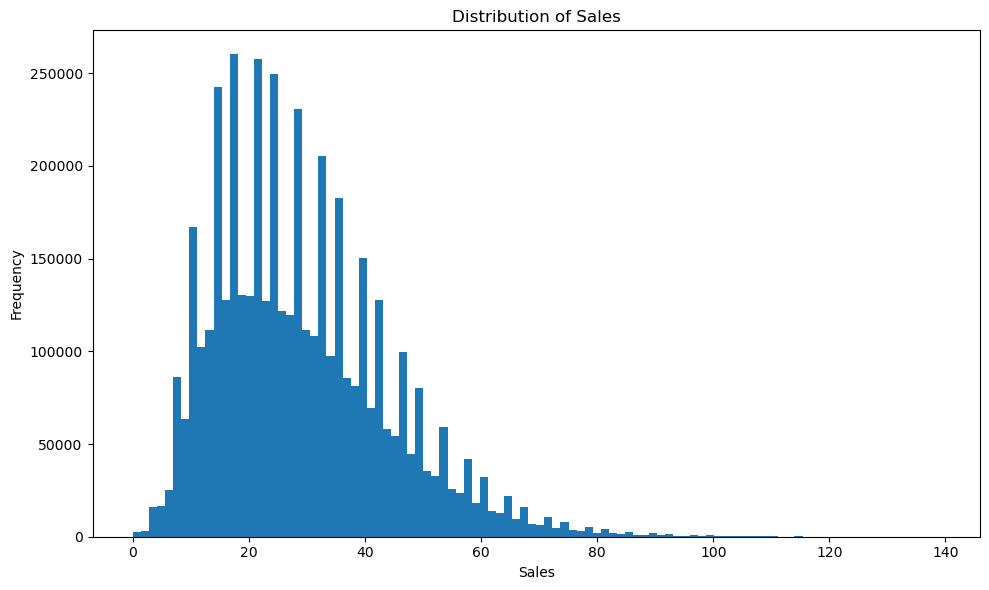

In [38]:
plt.figure(figsize=(10, 6))

plt.hist(df['sales'], bins=100)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
df = df.dropna().reset_index(drop=True)

In [40]:
print(df.shape)
print (df.isnull().sum().sum())

(4495000, 23)
0


In [41]:
train = df[df['date'] < '2023-01-01'].copy()

test = df[df['date'] >= '2023-01-01'].copy()

print("Training period:")
print(train['date'].min(), "to", train['date'].max())

print("\nTesting period:")
print(test['date'].min(), "to", test['date'].max())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

Training period:
2019-01-29 00:00:00 to 2022-12-31 00:00:00

Testing period:
2023-01-01 00:00:00 to 2023-12-31 00:00:00

Train shape: (3582500, 23)
Test shape: (912500, 23)


In [42]:
print(df.columns.tolist())

['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month', 'year', 'day', 'week', 'quarter', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_28', 'sales_rolling_std_7', 'price_change', 'promo_lag_1', 'promo_lag_7']


In [43]:
print(train.dtypes)

date                     datetime64[ns]
store_id                          int64
item_id                           int64
sales                             int64
price                           float64
promo                             int64
weekday                           int64
month                             int64
year                              int32
day                               int32
week                              int64
quarter                           int32
is_weekend                        int64
sales_lag_1                     float64
sales_lag_7                     float64
sales_lag_14                    float64
sales_lag_28                    float64
sales_rolling_mean_7            float64
sales_rolling_mean_28           float64
sales_rolling_std_7             float64
price_change                    float64
promo_lag_1                     float64
promo_lag_7                     float64
dtype: object


In [44]:
int_cols = [
    'store_id',
    'item_id',
    'sales',
    'promo',
    'weekday',
    'month',
    'week',
    'is_weekend'
]

for col in int_cols:
    train[col] = train[col].astype('int32')
    test[col] = test[col].astype('int32')

In [45]:
## Convert the floating-point columns

float_cols = [
    'price',
    'sales_lag_1',
    'sales_lag_7',
    'sales_lag_14',
    'sales_lag_28',
    'sales_rolling_mean_7',
    'sales_rolling_mean_28',
    'sales_rolling_std_7',
    'price_change',
    'promo_lag_1',
    'promo_lag_7'
]

for col in float_cols:
    train[col] = train[col].astype('float32')
    test[col] = test[col].astype('float32')

In [46]:
## Check the memory usage


print(
    "Train memory:",
    train.memory_usage(deep=True).sum() / (1024**3),
    "GB"
)

print(
    "Test memory:",
    test.memory_usage(deep=True).sum() / (1024**3),
    "GB"
)

Train memory: 0.346992164850235 GB
Test memory: 0.08838251233100891 GB


In [47]:
## Creating X and y
features = [
    'store_id',
    'item_id',
    'price',
    'promo',
    'weekday',
    'month',
    'year',
    'day',
    'week',
    'quarter',
    'is_weekend',
    'sales_lag_1',
    'sales_lag_7',
    'sales_lag_14',
    'sales_lag_28',
    'sales_rolling_mean_7',
    'sales_rolling_mean_28',
    'sales_rolling_std_7',
    'price_change',
    'promo_lag_1',
    'promo_lag_7'
]

X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

In [48]:
print(X_train.isna().sum())

print(X_test.isna().sum())

store_id                 0
item_id                  0
price                    0
promo                    0
weekday                  0
month                    0
year                     0
day                      0
week                     0
quarter                  0
is_weekend               0
sales_lag_1              0
sales_lag_7              0
sales_lag_14             0
sales_lag_28             0
sales_rolling_mean_7     0
sales_rolling_mean_28    0
sales_rolling_std_7      0
price_change             0
promo_lag_1              0
promo_lag_7              0
dtype: int64
store_id                 0
item_id                  0
price                    0
promo                    0
weekday                  0
month                    0
year                     0
day                      0
week                     0
quarter                  0
is_weekend               0
sales_lag_1              0
sales_lag_7              0
sales_lag_14             0
sales_lag_28             0
sales_rolling_m

In [49]:
# Confirming shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3582500, 21)
y_train: (3582500,)
X_test: (912500, 21)
y_test: (912500,)


In [50]:
# Checking the target variable
print(y_train.describe())

# Also
print(y_train.dtype)

count    3.582500e+06
mean     2.852347e+01
std      1.460354e+01
min      0.000000e+00
25%      1.700000e+01
50%      2.600000e+01
75%      3.700000e+01
max      1.350000e+02
Name: sales, dtype: float64
int32


In [51]:
# Checking the feature memory
print("X_train memory:",X_train.memory_usage(deep=True).sum() / (1024**3),"GB")

X_train memory: 0.30695460736751556 GB


In [52]:
## Create a 500,000-row training sample

sample_size = 500_000

X_train_sample = X_train.iloc[-sample_size:]
y_train_sample = y_train.iloc[-sample_size:]

print("Sample X:", X_train_sample.shape)
print("Sample y:", y_train_sample.shape)

Sample X: (500000, 21)
Sample y: (500000,)


In [53]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTarget:")
print(y_train.describe())

print("\nX_train memory:")
print(X_train.memory_usage(deep=True).sum() / (1024**3), "GB")

X_train: (3582500, 21)
y_train: (3582500,)
X_test: (912500, 21)
y_test: (912500,)

Target:
count    3.582500e+06
mean     2.852347e+01
std      1.460354e+01
min      0.000000e+00
25%      1.700000e+01
50%      2.600000e+01
75%      3.700000e+01
max      1.350000e+02
Name: sales, dtype: float64

X_train memory:
0.30695460736751556 GB


In [54]:
# Train a smaller HistGradientBoosting model
# Use fewer iterations initially:

from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)

# Train
model.fit(X_train_sample, y_train_sample)

,loss,'squared_error'
,quantile,None
,learning_rate,0.08
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,50
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [55]:
# Predict on the complete 2023 test set
y_pred = model.predict(X_test)

In [56]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.6319802740818856
RMSE: 3.3163731520847404
R²: 0.9586659995291655


In [57]:
print("Number of stores:", train['store_id'].nunique())
print("Number of items:", train['item_id'].nunique())

print("\nLast training date:")
print(train['date'].max())

Number of stores: 50
Number of items: 50

Last training date:
2022-12-31 00:00:00


In [58]:
# Building a better representative sample
# Instead of simply taking the last 500,000 rows, let's sample the training data while preserving the diversity of stores and items.
sample_size = 500_000

train_sample = train.sample(
    n=sample_size,
    random_state=42)

X_train_sample = train_sample[features]
y_train_sample = train_sample['sales']

print("X_train_sample:", X_train_sample.shape)
print("y_train_sample:", y_train_sample.shape)

# checking the coverage:
print("Stores represented:", X_train_sample['store_id'].nunique())
print("Items represented:", X_train_sample['item_id'].nunique())

X_train_sample: (500000, 21)
y_train_sample: (500000,)
Stores represented: 50
Items represented: 50


In [59]:
# Training the same model
model_sample = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.08, max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=1.0, random_state=42)
model_sample.fit(X_train_sample, y_train_sample)

# Predict:
y_pred_sample = model_sample.predict(X_test)

# Evaluate:
mae = mean_absolute_error(y_test, y_pred_sample)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sample))
r2 = r2_score(y_test, y_pred_sample)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.622436170587414
RMSE: 3.299797122848253
R²: 0.9590781614227933


In [60]:
# Create a smaller evaluation sample
from sklearn.inspection import permutation_importance

X_importance = X_test.sample(n=20_000, random_state=42)

y_importance = y_test.loc[X_importance.index]

print(X_importance.shape)
print(y_importance.shape)

(20000, 21)
(20000,)


In [61]:
# Calculate feature importance
perm_importance = permutation_importance(
    model_sample,
    X_importance,
    y_importance,
    n_repeats=3,
    random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1)

# Display the features
importance_df = pd.DataFrame({
    'feature': X_importance.columns,
    'importance': perm_importance.importances_mean
}).sort_values(
    by='importance',
    ascending=False)

print(importance_df)

                  feature  importance
16  sales_rolling_mean_28    3.647894
3                   promo    2.182455
12            sales_lag_7    2.166500
15   sales_rolling_mean_7    1.926577
13           sales_lag_14    1.545090
4                 weekday    1.166771
11            sales_lag_1    0.566173
8                    week    0.258328
14           sales_lag_28    0.195413
20            promo_lag_7    0.159256
18           price_change    0.048307
5                   month    0.023307
17    sales_rolling_std_7    0.009769
19            promo_lag_1    0.009736
10             is_weekend    0.008688
1                 item_id    0.000007
7                     day    0.000000
6                    year    0.000000
2                   price    0.000000
0                store_id    0.000000
9                 quarter   -0.000054


In [62]:
# Train a model using the strongest features
# Creating a smaller feature set:
top_features = [
    'store_id',
    'item_id',
    'price',
    'promo',
    'weekday',
    'week',
    'sales_lag_1',
    'sales_lag_7',
    'sales_lag_14',
    'sales_rolling_mean_7',
    'sales_rolling_mean_28',
    'promo_lag_7'
]

# creating the training and testing data:
X_train_top = train_sample[top_features]
y_train_top = train_sample['sales']

X_test_top = test[top_features]
y_test_top = test['sales']

print("Training:", X_train_top.shape)
print("Testing:", X_test_top.shape)

# Train the reduced-feature model
model_top = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)
model_top.fit(X_train_top, y_train_top)

# Then predict:
y_pred_top = model_top.predict(X_test_top)

# Evaluate it:
mae_top = mean_absolute_error(y_test_top, y_pred_top)
rmse_top = np.sqrt(mean_squared_error(y_test_top, y_pred_top))
r2_top = r2_score(y_test_top, y_pred_top)
print("MAE:", mae_top)
print("RMSE:", rmse_top)
print("R²:", r2_top)

Training: (500000, 12)
Testing: (912500, 12)
MAE: 2.6360261826154083
RMSE: 3.319263595850663
R²: 0.9585939173700307


In [63]:
# *Hyperparameter tuning*
# Now we can try to improve the model rather than changing the features.
model_tuned = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)

model_tuned.fit(X_train_sample, y_train_sample)

# Predict:
y_pred_tuned = model_tuned.predict(X_test)

# Evaluate:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)
print("MAE:", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²:", r2_tuned)

MAE: 2.6234222761355546
RMSE: 3.3020977416801287
R²: 0.9590210801125776


In [64]:
import gc

del model_tuned
gc.collect()

# Then train:
model_complex = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)
model_complex.fit(X_train_sample, y_train_sample)

# Predict:
y_pred_complex = model_complex.predict(X_test)

# Evaluate:
mae_complex = mean_absolute_error(y_test, y_pred_complex)
rmse_complex = np.sqrt(mean_squared_error(y_test, y_pred_complex))
r2_complex = r2_score(y_test, y_pred_complex)

print("MAE:", mae_complex)
print("RMSE:", rmse_complex)
print("R²:", r2_complex)

MAE: 2.5869990095393756
RMSE: 3.2517057772543434
R²: 0.9602622618156822


In [65]:
# Free memory
import gc
del model_complex
gc.collect()

# Train the regularized model
model_reg = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    l2_regularization=2.0,
    random_state=42)
model_reg.fit(X_train_sample, y_train_sample)

# Predict
y_pred_reg = model_reg.predict(X_test)

# Evaluate
mae_reg = mean_absolute_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2_reg = r2_score(y_test, y_pred_reg)

print("MAE:", mae_reg)
print("RMSE:", rmse_reg)
print("R²:", r2_reg)

MAE: 2.588363065093433
RMSE: 3.2532989858267523
R²: 0.9602233124030993


In [66]:
# min_samples_leaf=100

# First free the previous model:
import gc
del model_reg
gc.collect()

# Then:
model_leaf = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=100,
    l2_regularization=1.0,
    random_state=42)
model_leaf.fit(X_train_sample, y_train_sample)

# Predict:
y_pred_leaf = model_leaf.predict(X_test)

# Evaluate:
mae_leaf = mean_absolute_error(y_test, y_pred_leaf)
rmse_leaf = np.sqrt(mean_squared_error(y_test, y_pred_leaf))
r2_leaf = r2_score(y_test, y_pred_leaf)

print("MAE:", mae_leaf)
print("RMSE:", rmse_leaf)
print("R²:", r2_leaf)

MAE: 2.5881415831922583
RMSE: 3.2543113868652185
R²: 0.9601985521668882


In [67]:
# Create a validation period
# Use the last part of 2022 as validation:

train_core = train[train['date'] < '2022-10-01']
validation = train[train['date'] >= '2022-10-01']

print("Core training:", train_core.shape)
print("Validation:", validation.shape)

# Sample the core training data
train_core_sample = train_core.sample(
    n=500_000,
    random_state=42)
X_core = train_core_sample[features]
y_core = train_core_sample['sales']

X_val = validation[features]
y_val = validation['sales']

print("Core sample:", X_core.shape)
print("Validation:", X_val.shape)

# Train our current champion configuration
# First clean up the previous model:
import gc
del model_leaf
gc.collect()

# Then:
final_candidate = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)
final_candidate.fit(X_core, y_core)

# Evaluate on 2022 validation
val_pred = final_candidate.predict(X_val)
val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)

Core training: (3352500, 23)
Validation: (230000, 23)
Core sample: (500000, 21)
Validation: (230000, 21)
Validation MAE: 2.547131819188001
Validation RMSE: 3.1953679620866158
Validation R²: 0.9309495612180232


In [70]:
## Final candidate model
import gc
del final_candidate
gc.collect()

# Now I train champion configuration on the 500,000-row representative training sample:
from sklearn.ensemble import HistGradientBoostingRegressor

final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42)
final_model.fit(X_train_sample, y_train_sample)

print("Final model training completed.")

# Make the 2023 predictions
y_pred_final = final_model.predict(X_test)

# Final evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)
print("FINAL MODEL RESULTS")
print("-------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final model training completed.
FINAL MODEL RESULTS
-------------------
MAE : 2.5869990095393756
RMSE: 3.2517057772543434
R²  : 0.9602622618156822


In [71]:
## Check actual vs predicted sales
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final})

comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison['Absolute_Error'] = abs(comparison['Error'])
print(comparison.head(20))

    Actual  Predicted     Error  Absolute_Error
0       41  38.811069  2.188931        2.188931
1       48  44.879635  3.120365        3.120365
2       59  53.885986  5.114014        5.114014
3       53  52.803218  0.196782        0.196782
4       57  51.027038  5.972962        5.972962
5       46  43.110064  2.889936        2.889936
6       38  39.668200 -1.668200        1.668200
7       44  41.314040  2.685960        2.685960
8       45  47.350286 -2.350286        2.350286
9       54  56.764831 -2.764831        2.764831
10      56  54.396626  1.603374        1.603374
11      52  54.928279 -2.928279        2.928279
12      42  45.742414 -3.742414        3.742414
13      43  38.645921  4.354079        4.354079
14      41  42.402185 -1.402185        1.402185
15      51  47.423082  3.576918        3.576918
16      56  56.683163 -0.683163        0.683163
17      55  57.917844 -2.917844        2.917844
18      56  53.594817  2.405183        2.405183
19      41  45.457308 -4.457308        4

In [72]:
## Calculate average prediction bias
bias = np.mean(y_pred_final - y_test.values)

print("Prediction Bias:", bias)

Prediction Bias: -0.0768497649586486


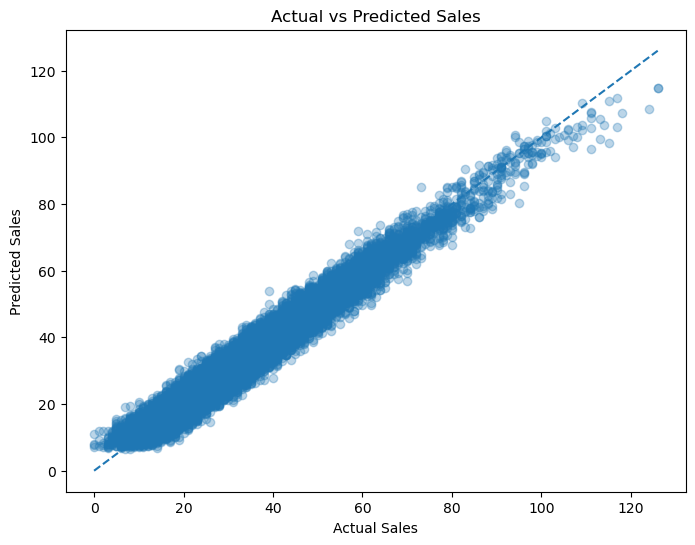

In [74]:
## Let's visualize Actual vs Predicted
import matplotlib.pyplot as plt

plot_sample = comparison.sample(
    n=20_000,
    random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_sample['Actual'],
    plot_sample['Predicted'],
    alpha=0.3)

# Perfect prediction line
min_value = min(
    plot_sample['Actual'].min(),
    plot_sample['Predicted'].min())

max_value = max(
    plot_sample['Actual'].max(),
    plot_sample['Predicted'].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

In [75]:
## Analyze prediction errors
comparison['Absolute_Error'].describe()
print(comparison.sort_values('Absolute_Error',ascending=False).head(20))


# Calculate error by sales level
comparison['Sales_Band'] = pd.cut(
    comparison['Actual'],
    bins=[-1, 10, 20, 30, 40, 60, 1000],
    labels=[ '0-10','11-20', '21-30', '31-40', '41-60', '60+'])

error_by_band = comparison.groupby('Sales_Band',observed=False).agg(MAE=('Absolute_Error', 'mean'), Count=('Actual', 'size'))

print(error_by_band)

        Actual   Predicted      Error  Absolute_Error
515453     139  110.192120  28.807880       28.807880
504503     132  106.831005  25.168995       25.168995
515446     136  111.025726  24.974274       24.974274
54886      129  105.029246  23.970754       23.970754
511108     138  114.301945  23.698055       23.698055
693629     130  106.319312  23.680688       23.680688
492844     135  112.432169  22.567831       22.567831
205182     133  110.474397  22.525603       22.525603
492865     133  111.158428  21.841572       21.841572
515461     130  108.203074  21.796926       21.796926
54823      136  114.562300  21.437700       21.437700
515501     131  109.745031  21.254969       21.254969
693637     119   98.288897  20.711103       20.711103
693552     131  110.474397  20.525603       20.525603
693559     131  110.619484  20.380516       20.380516
54885      123  102.982965  20.017035       20.017035
59252      131  111.062631  19.937369       19.937369
693566     130  110.244111  

In [76]:
## Save the model and feature configuration
import joblib
import os

# Save model
joblib.dump( final_model, "sales_forecasting_model.pkl")

# Save feature names
joblib.dump(X_train_sample.columns.tolist(),"sales_model_features.pkl")

print("Model and feature list saved successfully.")

print("\nFiles:")
print(os.path.exists("sales_forecasting_model.pkl"))
print(os.path.exists("sales_model_features.pkl"))

Model and feature list saved successfully.

Files:
True
True


In [77]:
## Create a reusable prediction function
def predict_sales(model, input_data):
    """
    Predict sales using the trained forecasting model.
    """

    prediction = model.predict(input_data)

    return prediction

## Test it using a few existing 2023 records:
sample_input = X_test.iloc[:5]
sample_predictions = predict_sales(final_model, sample_input)

print(sample_predictions)

[38.81106865 44.87963535 53.885986   52.80321781 51.02703849]


In [78]:
## Create a prediction results table
prediction_demo = pd.DataFrame({
    "Actual Sales": y_test.iloc[:5].values,
    "Predicted Sales": sample_predictions})

prediction_demo["Error"] = ( prediction_demo["Actual Sales"] - prediction_demo["Predicted Sales"])

prediction_demo

,Actual Sales,Predicted Sales,Error
0,41,38.811069,2.188931
1,48,44.879635,3.120365
2,59,53.885986,5.114014
3,53,52.803218,0.196782
4,57,51.027038,5.972962
